# A notebook for fine-tuning fingerprint model generated after transfer learning of mobilenet pre-trained model 

## Project Pre-requisites

In [1]:
# Import libraries
import os
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, saving

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.utils import image_dataset_from_directory

# pre-trained model selection
MobileNet_version = "MobileNetV2"
fingerprint_model_name = MobileNet_version + "_FingerPrint_Model"
fingerprint_basemodel_name = MobileNet_version + "_FingerPrint_BaseModel"

if MobileNet_version == "MobileNet":
    from tensorflow.keras.applications import MobileNet
    from tensorflow.keras.applications.mobilenet import preprocess_input
elif MobileNet_version == "MobileNetV2":
    from tensorflow.keras.applications import MobileNetV2
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
elif MobileNet_version == "MobileNetV3Small":
    from tensorflow.keras.applications import MobileNetV3Small
    from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
elif MobileNet_version == "MobileNetV3Large":
    from tensorflow.keras.applications import MobileNetV3Large
    from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
else:
    print("Unknown MobileNet version name")
    exit(0)

In [2]:
# Check selected pre-trained model
print(f"Selected pre-trained model version : {MobileNet_version}")
print(f"Fingerprint model name : {fingerprint_model_name}")

Selected pre-trained model version : MobileNetV2
Fingerprint model name : MobileNetV2_FingerPrint_Model


In [3]:
# Configuration GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU (entraînement sera lent)")
except Exception as e:
    print(f"Configuration GPU: {e}")

print(f"\n📦 Versions des bibliothèques :")
print(f"  - TensorFlow : {tf.__version__}")
print(f"  - Keras      : {keras.__version__}")
print(f"  - NumPy      : {np.__version__}")

print(f"\n🚀 Prêt pour le transfer learning en computer vision !")

✅ GPU(s) détecté(s): 1 - Croissance mémoire activée

📦 Versions des bibliothèques :
  - TensorFlow : 2.16.2
  - Keras      : 3.13.2
  - NumPy      : 1.26.4

🚀 Prêt pour le transfer learning en computer vision !


## Project Constants

In [4]:
# Random seeding 
TENSORFLOW_SEED = 42
tf.random.set_seed(TENSORFLOW_SEED)

NUMPY_SEED = 42
np.random.seed(NUMPY_SEED)

# Dataset configuration

DATASET_ROOTDIR_PATH = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Custom" 
print(f"📁 Fingerprints dataset images root directory path : {DATASET_ROOTDIR_PATH}")

# labels
# class_names = ['thumb', 'index', 'middle', 'ring', 'little']
class_names = ['thumb', 'index']

num_classes = len(class_names)
print(f"\n👁️ fingerprints classes : {class_names}")

# model name
fingerprint_model_basename = fingerprint_model_name + "_" + str(num_classes) + "_classes"
print(f"Adjusted fingerprint model name : {fingerprint_model_basename}")

📁 Fingerprints dataset images root directory path : /Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Custom

👁️ fingerprints classes : ['thumb', 'index']
Adjusted fingerprint model name : MobileNetV2_FingerPrint_Model_2_classes


In [5]:
print("🔧 Datasets creation for training and validation/test ...\n")

# Dataset creation parameters
BATCH_SIZE = 64
IMAGE_SIZE = (96, 96)

# Create traning dataset with class filtering
dataset_train_dir = DATASET_ROOTDIR_PATH + "/train"
train_ds = image_dataset_from_directory(
    dataset_train_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # One-hot encoding for multi-class
    class_names=class_names  # Explicitly specify the class names to ensure correct mapping
)

# Create validation dataset with the same class names to ensure correct mapping
dataset_val_dir = DATASET_ROOTDIR_PATH + "/validation"
val_test_ds = image_dataset_from_directory(
    dataset_val_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=class_names  # Same order of classes
)

# split validation dataset into 2 using 2/3 validation and 1/3 test ratio
val_batches = tf.data.experimental.cardinality(val_test_ds)
test_ds_cardinality = int(val_batches * 33 / 100)

test_ds = val_test_ds.take(test_ds_cardinality)
test_ds.class_names = class_names
val_ds = val_test_ds.skip(test_ds_cardinality)
val_ds.class_names = class_names

print(f"✅ Datasets created !\n")

print(f"📊 Training, validation and datasets information:")
print(f"  - Training Dataset Classes        : {train_ds.class_names}")
print(f"  - Validation Dataset Classes      : {val_ds.class_names}")
print(f"  - Test Dataset Classes            : {test_ds.class_names}")

# Checking number of classes in both datasets
if len(train_ds.class_names) != num_classes:
    print(f"\n⚠️  Error : {len(train_ds.class_names)} classes found instead of {num_classes} in training dataset !")
    print(f"   Classes found: {train_ds.class_names}\n")
elif len(val_test_ds.class_names) != num_classes:
    print(f"\n⚠️  Error : {len(val_test_ds.class_names)} classes found instead of {num_classes} in validation dataset !")
    print(f"   Classes found : {val_test_ds.class_names}")
else:
    print(f"  - ✅ Number of correct classes : {num_classes} \n")

print(f"  - Training batches    : {len(train_ds)}")
print(f"  - Validation batches  : {len(val_ds)}")
print(f"  - Test batches        : {len(test_ds)}")
print(f"  - Batch size          : {BATCH_SIZE}")
print(f"  - Training samples    : ~{len(train_ds) * BATCH_SIZE}")
print(f"  - Validation samples  : ~{len(val_ds) * BATCH_SIZE}")
print(f"  - Test samples        : ~{len(test_ds) * BATCH_SIZE}")

🔧 Datasets creation for training and validation/test ...

Found 6382 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
✅ Datasets created !

📊 Training, validation and datasets information:
  - Training Dataset Classes        : ['thumb', 'index']
  - Validation Dataset Classes      : ['thumb', 'index']
  - Test Dataset Classes            : ['thumb', 'index']
  - ✅ Number of correct classes : 2 

  - Training batches    : 100
  - Validation batches  : 9
  - Test batches        : 4
  - Batch size          : 64
  - Training samples    : ~6400
  - Validation samples  : ~576
  - Test samples        : ~256


2026-03-26 08:14:41.350556: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-03-26 08:14:41.350588: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-26 08:14:41.350599: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-26 08:14:41.350620: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-26 08:14:41.350632: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Dataset Preparation : normalization and shuffling (training only), no augmentation

In [6]:
print("🎨 Fingerprint dataset preparation : normalisation and shuffling (training only) ...\n")

# Dataset preparation function
def prepare_dataset(ds, shuffle=True):

    # normalisation required for MobileNet
    normalization = lambda x, y: (preprocess_input(x), y)
    ds = ds.map(normalization, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Shuffle (training only)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    
    # Performances optimisation
    ds = ds.cache()  # Memory caching
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)  # Prefetch for acceleration
    
    return ds

# Apply transformations
train_ds_prepared = prepare_dataset(train_ds, shuffle=True)
val_ds_prepared = prepare_dataset(val_ds, shuffle=False)
test_ds_prepared = prepare_dataset(test_ds, shuffle=False)

print("✅ Dataset preparation completed !\n")

print("📝 Applied transformations :")
print("  - Training dataset             : normalisation + shuffle")
print("  - Validation and test dataset  : normalisation only")
print("\n  - Caching et prefetch activated for performance")

🎨 Fingerprint dataset preparation : normalisation and shuffling (training only) ...

✅ Dataset preparation completed !

📝 Applied transformations :
  - Training dataset             : normalisation + shuffle
  - Validation and test dataset  : normalisation only

  - Caching et prefetch activated for performance


## Loading Frozen Previously Trained model with Pre-Trained MobileNet base model 

In [7]:
fingerprint_model_dir = "/Users/laurent/Projects/projet-fingerprint-validator/models"
fingerprint_model_name = fingerprint_model_basename + "_Transfer_Learning.keras"
fingerprint_model_path = fingerprint_model_dir + "/" + fingerprint_model_name

print(f"📥 Loading Frozen Previously Trained {fingerprint_model_name} model ...")

# Loading frozen fingerprint model
try:
    frozen_fingerprint_model = tf.keras.models.load_model(fingerprint_model_path, compile=True)
except Exception as e:
    print(f"Unable to load pre-trained model {fingerprint_model_path} : {e}")
    exit(0)

print(f"✅ {fingerprint_model_name} model loaded !\n")

# Display model structure
print(f"📋 Model Structure - {fingerprint_model_name} :")
print(f"  - Input shape    : {frozen_fingerprint_model.input_shape}")
print(f"  - Output shape   : {frozen_fingerprint_model.output_shape}")
print(f"  - Number of layers : {len(frozen_fingerprint_model.layers)}")

# Count parameters
total_params = frozen_fingerprint_model.count_params()
print(f"\n  - Total number of parameters : {total_params:,}")
print(f"  - Memory size (approx.) : {total_params * 4 / (1024**2):.1f} MB")

📥 Loading Frozen Previously Trained MobileNetV2_FingerPrint_Model_2_classes_Transfer_Learning.keras model ...
✅ MobileNetV2_FingerPrint_Model_2_classes_Transfer_Learning.keras model loaded !

📋 Model Structure - MobileNetV2_FingerPrint_Model_2_classes_Transfer_Learning.keras :
  - Input shape    : (None, 96, 96, 3)
  - Output shape   : (None, 2)
  - Number of layers : 8

  - Total number of parameters : 2,602,498
  - Memory size (approx.) : 9.9 MB


In [8]:
print(f"🔍 {fingerprint_model_name} pre-trained model architecture\n")
print("="*60)

def get_output_shape(layer):
    try:
        if hasattr(layer, 'output_shape'):
            return str(layer.output_shape)
        elif hasattr(layer, 'output'):
            return str(layer.output.shape)
        else:
            return "N/A"
    except:
        return "N/A"

# Display layers
frozen_fingerprint_basemodel = None

print("\n📌 Model layers (low-level feature extraction) :")
for i, layer in enumerate(frozen_fingerprint_model.layers):
    output_shape = get_output_shape(layer)
    if layer.name == fingerprint_basemodel_name:
        frozen_fingerprint_basemodel = layer

    print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")

print("\n      ...")

print("\n" + "="*60)

🔍 MobileNetV2_FingerPrint_Model_2_classes_Transfer_Learning.keras pre-trained model architecture


📌 Model layers (low-level feature extraction) :
    1. input_layer_1                            | Output: (None, 96, 96, 3)              | Trainable: True
    2. MobileNetV2_FingerPrint_BaseModel        | Output: (None, 1280)                   | Trainable: False
    3. dropout                                  | Output: (None, 1280)                   | Trainable: True
    4. dense                                    | Output: (None, 256)                    | Trainable: True
    5. dropout_1                                | Output: (None, 256)                    | Trainable: True
    6. dense_1                                  | Output: (None, 64)                     | Trainable: True
    7. dropout_2                                | Output: (None, 64)                     | Trainable: True
    8. dense_2                                  | Output: (None, 2)                      | Trainable: T

In [9]:
print(f"🔍 {MobileNet_version} pre-trained model architecture\n")
print("="*60)

# Display the first 10 and last 10 layers of the base model to understand the feature extraction process
print("\n📌 First layers (low-level feature extraction) :")
for i, layer in enumerate(frozen_fingerprint_basemodel.layers[:10]):
    output_shape = get_output_shape(layer)
    print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")

print("\n      ...")

print("\n📌 Last layers (high-level features) :")
for i, layer in enumerate(frozen_fingerprint_basemodel.layers[-10:], start=len(frozen_fingerprint_basemodel.layers)-10):
    output_shape = get_output_shape(layer)
    print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")

print("\n" + "="*60)

🔍 MobileNetV2 pre-trained model architecture


📌 First layers (low-level feature extraction) :
    1. input_layer                              | Output: (None, 96, 96, 3)              | Trainable: True
    2. Conv1                                    | Output: (None, 48, 48, 32)             | Trainable: False
    3. bn_Conv1                                 | Output: (None, 48, 48, 32)             | Trainable: False
    4. Conv1_relu                               | Output: (None, 48, 48, 32)             | Trainable: False
    5. expanded_conv_depthwise                  | Output: (None, 48, 48, 32)             | Trainable: False
    6. expanded_conv_depthwise_BN               | Output: (None, 48, 48, 32)             | Trainable: False
    7. expanded_conv_depthwise_relu             | Output: (None, 48, 48, 32)             | Trainable: False
    8. expanded_conv_project                    | Output: (None, 48, 48, 16)             | Trainable: False
    9. expanded_conv_project_BN           

In [10]:
frozen_fingerprint_model.summary()

Model: "MobileNetV2_FingerPrint_Model_2_classes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV2_FingerPrint_BaseMo… │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,291,528 (12.56 MB)

 Trainable params: 344,514 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 689,030 (2.63 MB)

## Evaluation before Fine-Tuning

In [11]:
print("📈 Evaluation before fine-tuning :")

# Perform evaluation BEFORE fine-tuning
results_before = frozen_fingerprint_model.evaluate(test_ds_prepared, verbose=0)

print(f"  - Accuracy : {results_before[1]*100:.2f}%")
print(f"  - Loss     : {results_before[0]:.4f}\n")

📈 Evaluation before fine-tuning :


2026-03-26 08:14:42.912181: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  - Accuracy : 87.50%
  - Loss     : 0.3623



## Fune-Tuning Preparation : unfreezing base model and recompile

In [12]:
# Constants

# Number of layers in the model 
NUM_BASE_MODEL_LAYERS = len(frozen_fingerprint_basemodel.layers)

# keep ratio of 1/3 unfrozen layers vs. 2/3 frozen layers
UNFROZEN_FROZEN_LAYERS_RATIO = 0.33
NUM_MODEL_UNFROZEN_BASE_MODEL_LAYERS = int(NUM_BASE_MODEL_LAYERS * UNFROZEN_FROZEN_LAYERS_RATIO)

#  ratio of unfrozen first layers vs. unfrozen last layers
UNFROZEN_FROZEN_INPUT_OUTPUT_LAYERS_RATIO = 0
FINE_TUNING_UNFROZEN_INPUT_BASE_MODEL_LAYERS = int(NUM_MODEL_UNFROZEN_BASE_MODEL_LAYERS * UNFROZEN_FROZEN_INPUT_OUTPUT_LAYERS_RATIO)
FINE_TUNING_UNFREEZE_OUTPUT_BASE_MODEL_LAYERS = int(NUM_MODEL_UNFROZEN_BASE_MODEL_LAYERS - FINE_TUNING_UNFROZEN_INPUT_BASE_MODEL_LAYERS)

# Low LR for fine tuning
FINE_TUNE_LR = 1e-5 

In [13]:
print("🔥 Fine-Tuning Preparation...\n")

# APPROCHE LA PLUS SIMPLE : Modifier le modèle frozen en place
print(f"💡 Strategy : unfreeze the {MobileNet_version} pre-trained base model and continue training\n")
print(f"Number of layers in the base model                      : {NUM_BASE_MODEL_LAYERS}")
print(f"Number of the first unfrozen layers in the base model   : {FINE_TUNING_UNFROZEN_INPUT_BASE_MODEL_LAYERS}")
print(f"Number of the last unfrozen layers in the base model   : {FINE_TUNING_UNFREEZE_OUTPUT_BASE_MODEL_LAYERS}")

# Unfreeze base model
frozen_fingerprint_basemodel.trainable = True

# Unfreeze the first FINE_TUNING_UNFREEZE_INPUT_BASE_MODEL_LAYERS-th layers
# Unfreeze the last FINE_TUNING_UNFREEZE_OUTPUT_BASE_MODEL_LAYERS-th layers

for i, layer in enumerate(frozen_fingerprint_basemodel.layers):
    if i < FINE_TUNING_UNFROZEN_INPUT_BASE_MODEL_LAYERS:
        layer.trainable = True
    elif i < (NUM_BASE_MODEL_LAYERS - FINE_TUNING_UNFREEZE_OUTPUT_BASE_MODEL_LAYERS):
        layer.trainable = False
    else:
        layer.trainable = True


print(f"📊 Unfreeze configuration :")
print(f"  - Frozen layers   : {NUM_MODEL_UNFROZEN_BASE_MODEL_LAYERS}")
print(f"  - Unfrozen layers : {len(frozen_fingerprint_basemodel.layers) - NUM_MODEL_UNFROZEN_BASE_MODEL_LAYERS}")

# Model params counting 
trainable_count = sum([tf.size(w).numpy() for w in frozen_fingerprint_basemodel.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in frozen_fingerprint_basemodel.non_trainable_weights])
total = trainable_count + non_trainable_count

print(f"  - Trainable params : {trainable_count:,} ({trainable_count/total*100:.1f}%)")
print(f"  - Frozen params    : {non_trainable_count:,}\n")

# Recompile model 
frozen_fingerprint_model.compile(
    optimizer=optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy', 
             keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy')]
)

# Fine-tuned model with partial frozen base model 
finetuned_fingerprint_model = frozen_fingerprint_model

print(f"✅ Fingerprint model {finetuned_fingerprint_model.name} recompiled with low LR = {FINE_TUNE_LR}")

🔥 Fine-Tuning Preparation...

💡 Strategy : unfreeze the MobileNetV2 pre-trained base model and continue training

Number of layers in the base model                      : 155
Number of the first unfrozen layers in the base model   : 0
Number of the last unfrozen layers in the base model   : 51
📊 Unfreeze configuration :
  - Frozen layers   : 51
  - Unfrozen layers : 104
  - Trainable params : 1,855,104 (82.2%)
  - Frozen params    : 402,880

✅ Fingerprint model MobileNetV2_FingerPrint_Model_2_classes recompiled with low LR = 1e-05


In [14]:
print(f"🔍 {MobileNet_version} pre-trained model architecture\n")
print("="*60)

# Display the first 10 and last 10 layers of the base model to verify unfreezing
print("\n📌 First layers (low-level feature extraction) :")
for i, layer in enumerate(frozen_fingerprint_basemodel.layers[:FINE_TUNING_UNFROZEN_INPUT_BASE_MODEL_LAYERS + 2]):
    output_shape = get_output_shape(layer)
    print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")

print("\n      ...")

print("\n📌 Last layers (high-level features) :")
for i, layer in enumerate(frozen_fingerprint_basemodel.layers[- FINE_TUNING_UNFREEZE_OUTPUT_BASE_MODEL_LAYERS -2:], start=len(frozen_fingerprint_basemodel.layers) - FINE_TUNING_UNFREEZE_OUTPUT_BASE_MODEL_LAYERS - 2):
    output_shape = get_output_shape(layer)
    print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")

print("\n" + "="*60)

🔍 MobileNetV2 pre-trained model architecture


📌 First layers (low-level feature extraction) :
    1. input_layer                              | Output: (None, 96, 96, 3)              | Trainable: False
    2. Conv1                                    | Output: (None, 48, 48, 32)             | Trainable: False

      ...

📌 Last layers (high-level features) :
  103. block_11_depthwise_BN                    | Output: (None, 6, 6, 576)              | Trainable: False
  104. block_11_depthwise_relu                  | Output: (None, 6, 6, 576)              | Trainable: False
  105. block_11_project                         | Output: (None, 6, 6, 96)               | Trainable: True
  106. block_11_project_BN                      | Output: (None, 6, 6, 96)               | Trainable: True
  107. block_11_add                             | Output: (None, 6, 6, 96)               | Trainable: True
  108. block_12_expand                          | Output: (None, 6, 6, 576)              | Trainable: 

In [15]:
finetuned_fingerprint_model.summary()

Model: "MobileNetV2_FingerPrint_Model_2_classes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV2_FingerPrint_BaseMo… │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,602,498 (9.93 MB)

 Trainable params: 2,199,618 (8.39 MB)

 Non-trainable params: 402,880 (1.54 MB)

In [16]:
# failsafe checking
print("\n🔍 Weigths failsafe checking :")
results_after_compile = finetuned_fingerprint_model.evaluate(test_ds_prepared, verbose=0)

frozen_accuracy = results_after_compile[1]
print(f"  - Accuracy : {frozen_accuracy*100:.2f}%")
print(f"  - Loss     : {results_after_compile[0]:.4f}")

if abs(results_after_compile[1] - results_before[1]) < 0.01:
    print(f"\n  ✅ Transfer-learning weigths have been preserved ({results_after_compile[1]*100:.1f}%)")
else:
    print(f"\n  ⚠️  Transfer-learning weigths have been affected after compile")


🔍 Weigths failsafe checking :
  - Accuracy : 87.50%
  - Loss     : 0.3623

  ✅ Transfer-learning weigths have been preserved (87.5%)


## Fine-Tuning Training

In [17]:
# Constants for training callbacks
EARLYSTOPPING_PATIENCE = 30
EARLYSTOPPING_VERBOSE = 1

REDUCELRONPLATEAU_FACTOR = 0.5
REDUCELRONPLATEAU_PATIENCE = 7
REDUCELRONPLATEAU_MIN_LR = 1e-8
REDUCELRONPLATEAU_VERBOSE = 1

fingerprint_model_name = MobileNet_version + "_FingerPrint_Model_" + str(num_classes) + "_classes_Fine_Tuning.keras"
MODELCHECKPOINT_PATH = fingerprint_model_dir + "/" + fingerprint_model_name
MODELCHECKPOINT_VERBOSE = 1

FIT_NUM_EPOCHS = 120
FIT_VERBOSE = 1

In [18]:
print("🚀 Fine-tuning FringerPrint Model...\n")

# Callbacks 
early_stopping_ft = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=EARLYSTOPPING_PATIENCE,
    restore_best_weights=True,
    mode='max',
    verbose=EARLYSTOPPING_VERBOSE
)

reduce_lr_ft = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=REDUCELRONPLATEAU_FACTOR,
    patience=REDUCELRONPLATEAU_PATIENCE,
    min_lr=REDUCELRONPLATEAU_MIN_LR,
    verbose=REDUCELRONPLATEAU_VERBOSE
)

checkpoint_ft = callbacks.ModelCheckpoint(
    MODELCHECKPOINT_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=MODELCHECKPOINT_VERBOSE
)

🚀 Fine-tuning FringerPrint Model...



In [19]:
print(f"Training for {FIT_NUM_EPOCHS} epochs maximum...\n")

history_finetuned = finetuned_fingerprint_model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=FIT_NUM_EPOCHS,
    callbacks=[early_stopping_ft, reduce_lr_ft, checkpoint_ft],
    verbose=FIT_VERBOSE
)

print("\n✅ Fine-tuning complete !")
print(f"   Number of epochs completed : {len(history_finetuned.history['loss'])}")

# Best performances
best_val_acc = max(history_finetuned.history['val_accuracy'])
best_epoch = history_finetuned.history['val_accuracy'].index(best_val_acc) + 1
print(f"   Meilleure val_accuracy : {best_val_acc*100:.2f}% (epoch {best_epoch})")

# Comparaison
improvement = (best_val_acc - frozen_accuracy) * 100

print(f"\n📊 Improvement vs Frozen  : {improvement:+.1f} %")
print(f"   - Frozen                 : {frozen_accuracy*100:.1f}%")
print(f"   - Fine-tuned             : {best_val_acc*100:.1f}%")

Training for 120 epochs maximum...

Epoch 1/120
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.7178 - loss: 0.6892 - top2_accuracy: 1.0000
Epoch 1: val_accuracy improved from None to 0.88235, saving model to /Users/laurent/Projects/projet-fingerprint-validator/models/MobileNetV2_FingerPrint_Model_2_classes_Fine_Tuning.keras

Epoch 1: finished saving model to /Users/laurent/Projects/projet-fingerprint-validator/models/MobileNetV2_FingerPrint_Model_2_classes_Fine_Tuning.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 226ms/step - accuracy: 0.7836 - loss: 0.5715 - top2_accuracy: 1.0000 - val_accuracy: 0.8824 - val_loss: 0.4114 - val_top2_accuracy: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/120
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9008 - loss: 0.3615 - top2_accuracy: 1.0000
Epoch 2: val_accuracy improved from 0.88235 to 0.88419, saving model to /Users/laurent/Projects/projet-fingerprint-validator/models/MobileNetV2_FingerPrint_Model_2_classes_Fine_Tuning.keras

Epoch 2

## Fine-Tuned Model Evaluation

In [20]:
print("🔍 Diagnostic of fine-tuned model\n")
print("="*150)

# Make a few predictions using test dataset
num_examples_predictions = 20
for images, labels in test_ds_prepared.take(1):
    predictions = finetuned_fingerprint_model.predict(images[:num_examples_predictions], verbose=0)
    
    print("\n📊 Prediction samples :")
    print("-"*150)
    
    for i in range(num_examples_predictions):

        example_predictions = np.copy(predictions[i])

        true_label = np.argmax(labels[i])
        top1_pred_label = np.argmax(example_predictions)
        top1_confidence = example_predictions[top1_pred_label]

        example_predictions[top1_pred_label] = 0
        top2_pred_label = np.argmax(example_predictions)
        top2_confidence = example_predictions[top2_pred_label]

        status = "✅" if true_label == top1_pred_label else "❌"
        print(f"{status} Image {i+1}: Label={class_names[true_label]:12s} | Prediction={class_names[top1_pred_label]:12s} | Confidence={top1_confidence*100:5.1f}% | 2nd Prediction={class_names[top2_pred_label]:12s} | 2nd Confidence={top2_confidence*100:5.1f}%")

print("\n" + "="*150)

🔍 Diagnostic of fine-tuned model


📊 Prediction samples :
------------------------------------------------------------------------------------------------------------------------------------------------------
❌ Image 1: Label=thumb        | Prediction=index        | Confidence= 90.5% | 2nd Prediction=thumb        | 2nd Confidence= 14.5%
✅ Image 2: Label=thumb        | Prediction=thumb        | Confidence= 97.5% | 2nd Prediction=index        | 2nd Confidence=  0.3%
✅ Image 3: Label=index        | Prediction=index        | Confidence= 99.5% | 2nd Prediction=thumb        | 2nd Confidence=  1.4%
✅ Image 4: Label=thumb        | Prediction=thumb        | Confidence= 99.7% | 2nd Prediction=index        | 2nd Confidence=  0.0%
✅ Image 5: Label=thumb        | Prediction=thumb        | Confidence= 98.8% | 2nd Prediction=index        | 2nd Confidence=  0.1%
✅ Image 6: Label=index        | Prediction=index        | Confidence= 91.7% | 2nd Prediction=thumb        | 2nd Confidence= 12.7%
❌ Image 7: 

2026-03-26 08:35:05.079213: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


📊 Evaluation of fine-tuned model using test dataset...

Results :
  - Loss                : 0.4707
  - Accuracy            : 90.62%
  - Top-2 Accuracy      : 100.00%


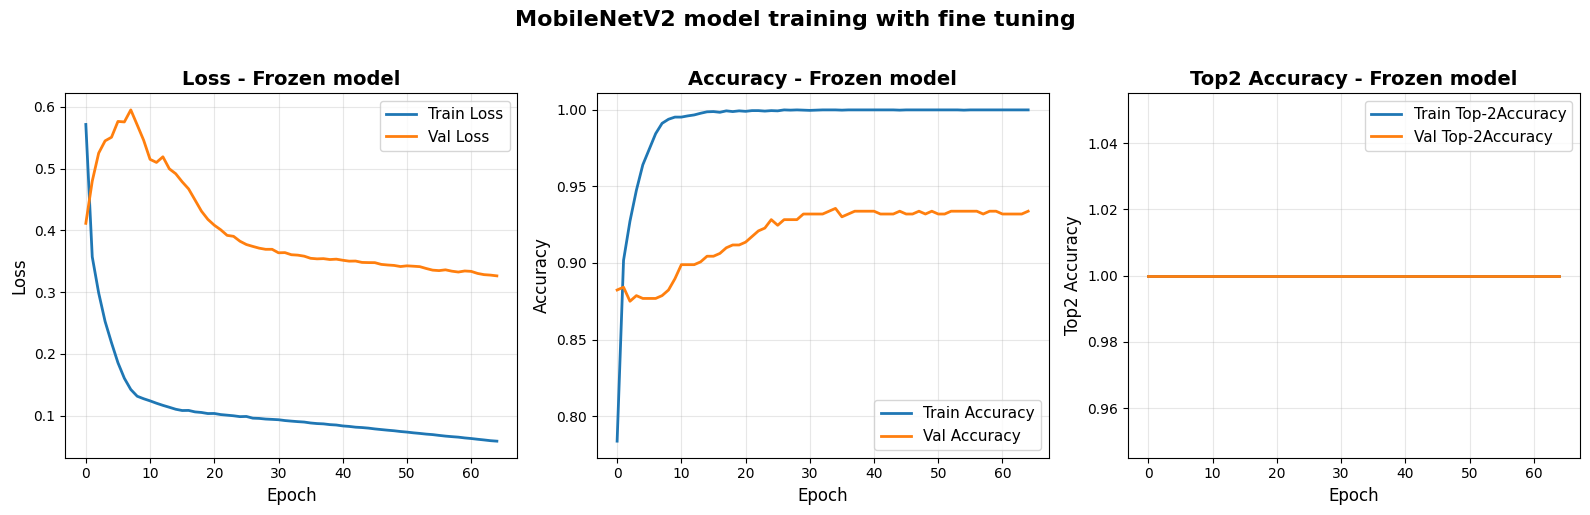

In [21]:
# Evaluation using test dataset
print("📊 Evaluation of fine-tuned model using test dataset...\n")

results_model_finetuned = finetuned_fingerprint_model.evaluate(test_ds_prepared, verbose=0)

print("Results :")
print(f"  - Loss                : {results_model_finetuned[0]:.4f}")
print(f"  - Accuracy            : {results_model_finetuned[1]*100:.2f}%")
print(f"  - Top-2 Accuracy      : {results_model_finetuned[2]*100:.2f}%")

# Display training grpahs
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loss
axes[0].plot(history_finetuned.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_finetuned.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss - Frozen model', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_finetuned.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history_finetuned.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy - Frozen model', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

# Top2 Accuracy
axes[2].plot(history_finetuned.history['top2_accuracy'], label='Train Top-2Accuracy', linewidth=2)
axes[2].plot(history_finetuned.history['val_top2_accuracy'], label='Val Top-2Accuracy', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Top2 Accuracy', fontsize=12)
axes[2].set_title('Top2 Accuracy - Frozen model', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(alpha=0.3)

plt.suptitle(f'{MobileNet_version} model training with fine tuning', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()